In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [4]:
# ============================================================
# PARAMÈTRES — ajuste alpha et beta ici
# Basés sur les ratios mesurés : BG/TC=203x, BG/AR=17x
# α/β ≈ 203/17 ≈ 12
ALPHA = 12.0   # poids TC
BETA  = 1.0    # poids AR (référence)
 
# Pourcentage de fichiers à garder (exemples à tester)
KEEP_PERCENTAGES = [0.25, 0.33, 0.50, 0.75]
# ============================================================

In [5]:
# ============================================================
# ÉTAPE 1 — Chargement du CSV déjà calculé
# ============================================================
try:
    df = pd.read_csv('train_class_distribution.csv')
    print(f'✅ CSV chargé — {len(df)} fichiers')
except FileNotFoundError:
    raise FileNotFoundError("Lance d'abord analyze_train.py pour générer train_class_distribution.csv")

✅ CSV chargé — 398 fichiers


In [6]:
# ============================================================
# ÉTAPE 2 — Calcul du score pondéré
# ============================================================
df['score'] = ALPHA * df['pct_tc'] + BETA * df['pct_ar']
df = df.sort_values('score', ascending=False).reset_index(drop=True)
 
print(f'\nα (TC) = {ALPHA}  |  β (AR) = {BETA}')
print(f'Score = {ALPHA}×pct_tc + {BETA}×pct_ar')
print()
print('=== STATISTIQUES DU SCORE ===')
print(f'  Min    : {df["score"].min():.4f}')
print(f'  Max    : {df["score"].max():.4f}')
print(f'  Moyenne: {df["score"].mean():.4f}')
print(f'  Médiane: {df["score"].median():.4f}')
print(f'  Std    : {df["score"].std():.4f}')
print()


α (TC) = 12.0  |  β (AR) = 1.0
Score = 12.0×pct_tc + 1.0×pct_ar

=== STATISTIQUES DU SCORE ===
  Min    : 1.4933
  Max    : 37.0542
  Moyenne: 11.2159
  Médiane: 10.3889
  Std    : 5.4988



In [7]:
# ============================================================
# ÉTAPE 3 — Simulation pour différents seuils
# ============================================================
print('=' * 65)
print('SIMULATION — Impact selon le % de fichiers gardés')
print('=' * 65)
print(f'{"% gardés":<12} {"N fichiers":<12} {"Seuil score":<14} {"TC pixels":<14} {"AR pixels":<14} {"Ratio BG/TC":<12} {"Ratio BG/AR"}')
print('-' * 90)
 
results = []
for pct in KEEP_PERCENTAGES:
    n_keep = int(len(df) * pct)
    subset = df.head(n_keep)
    threshold = subset['score'].min()
 
    total_tc = subset['n_tc'].sum()
    total_ar = subset['n_ar'].sum()
    total_bg = subset['n_bg'].sum()
    total    = total_tc + total_ar + total_bg
 
    ratio_tc = total_bg / max(total_tc, 1)
    ratio_ar = total_bg / max(total_ar, 1)
 
    pct_tc_kept = 100 * total_tc / df['n_tc'].sum()
    pct_ar_kept = 100 * total_ar / df['n_ar'].sum()
 
    results.append({
        'pct_kept': pct, 'n_keep': n_keep, 'threshold': threshold,
        'total_tc': total_tc, 'total_ar': total_ar, 'total_bg': total_bg,
        'ratio_tc': ratio_tc, 'ratio_ar': ratio_ar,
        'pct_tc_kept': pct_tc_kept, 'pct_ar_kept': pct_ar_kept
    })
 
    print(f'{100*pct:>6.0f}%      {n_keep:<12} {threshold:<14.4f} {total_tc:<14,} {total_ar:<14,} {ratio_tc:<12.0f} {ratio_ar:.0f}')
 
print()
print('% de pixels TC/AR conservés par seuil :')
print(f'{"% gardés":<12} {"% TC conservé":<18} {"% AR conservé"}')
print('-' * 45)
for r in results:
    print(f'{100*r["pct_kept"]:>6.0f}%      {r["pct_tc_kept"]:>10.1f}%         {r["pct_ar_kept"]:>10.1f}%')

SIMULATION — Impact selon le % de fichiers gardés
% gardés     N fichiers   Seuil score    TC pixels      AR pixels      Ratio BG/TC  Ratio BG/AR
------------------------------------------------------------------------------------------
    25%      99           13.8436        865,705        6,064,684      93           13
    33%      131          12.4556        1,029,920      7,788,987      104          14
    50%      199          10.4110        1,315,869      11,252,461     124          15
    75%      298          7.4994         1,551,880      16,257,446     158          15

% de pixels TC/AR conservés par seuil :
% gardés     % TC conservé      % AR conservé
---------------------------------------------
    25%            53.2%               30.4%
    33%            63.3%               39.0%
    50%            80.9%               56.3%
    75%            95.4%               81.4%


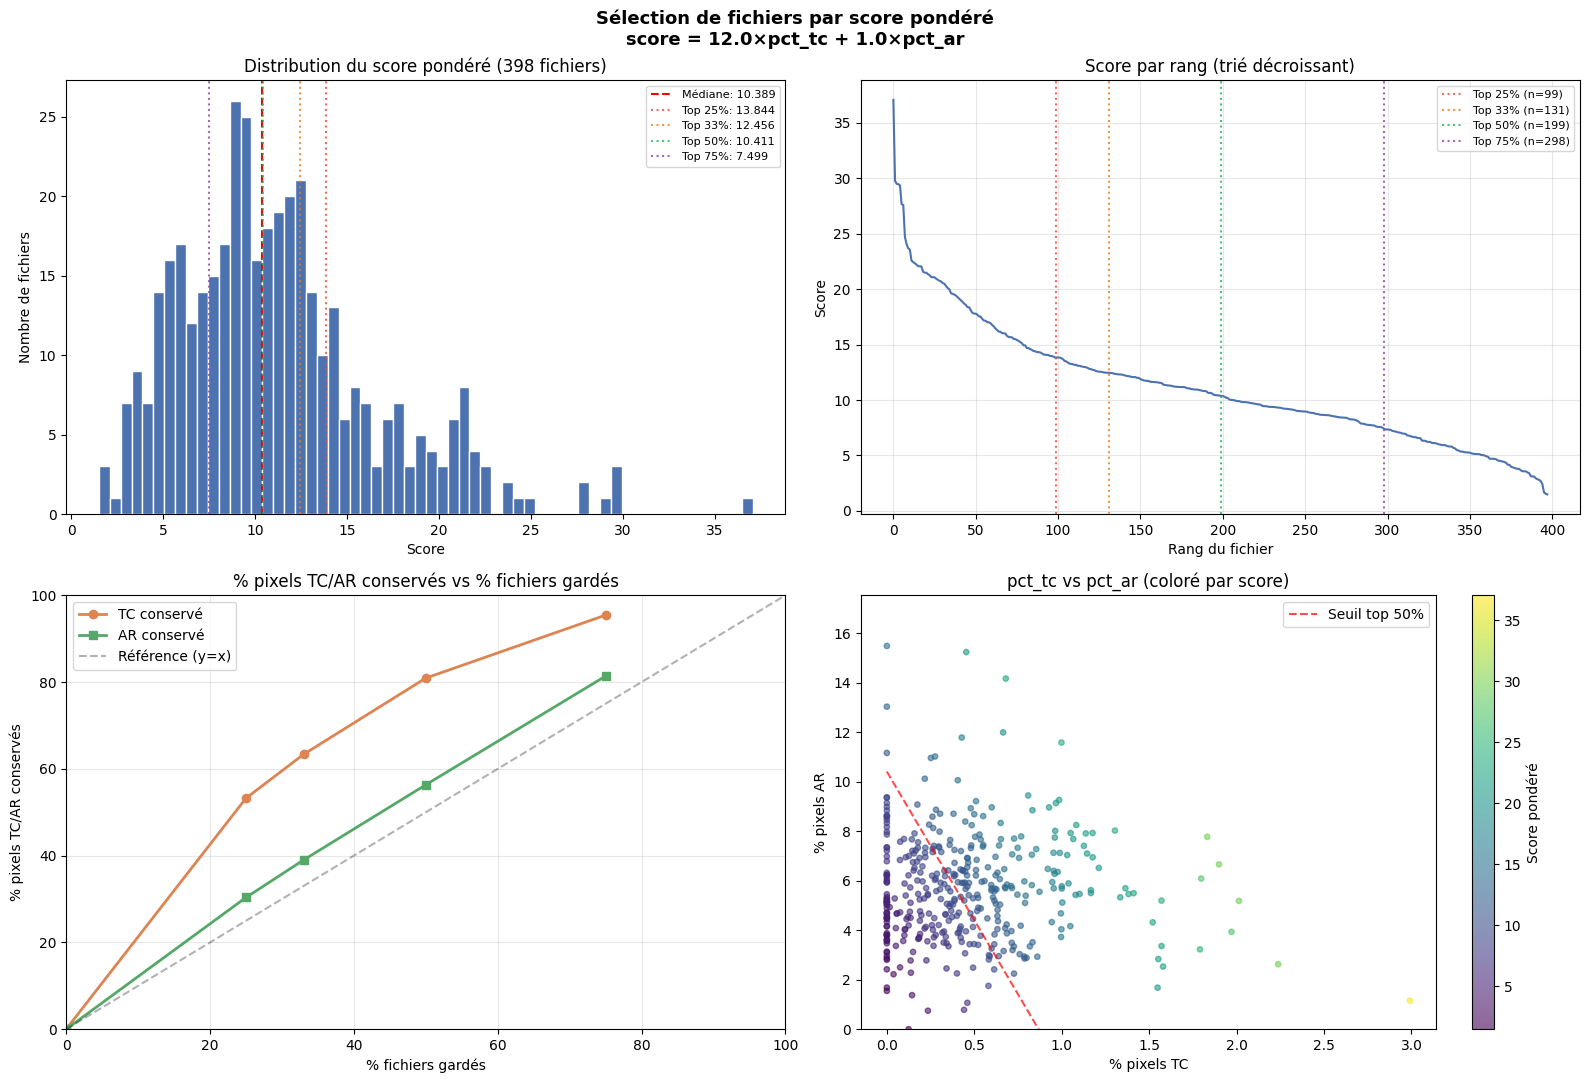

✅ Graphiques sauvegardés dans file_selection_score.png

RECOMMANDATION
Pour conserver ≥90% des pixels TC :
  → Garder top 64% des fichiers (254 fichiers)
  → TC conservé : 90.4%
  → AR conservé : 70.3%
  → Seuil score : 8.8617
  → Liste sauvegardée dans selected_files_top64pct.csv

Top 10 fichiers par score :
                 filename     score   pct_tc   pct_ar
data-2008-09-19-01-1_1.nc 37.054217 2.991514 1.156051
data-1997-08-14-01-1_2.nc 29.764811 1.832524 7.774523
data-2002-03-31-01-1_1.nc 29.480207 2.237843 2.626094
data-2000-01-06-01-1_2.nc 29.454210 1.899437 6.660970
data-2010-09-09-01-1_1.nc 29.343669 2.013369 5.183241
data-2000-09-28-01-1_0.nc 27.656499 1.797485 6.086674
data-2009-08-19-01-1_0.nc 27.583935 1.970757 3.934846
data-1996-09-01-01-1_1.nc 24.710987 1.790478 3.225256
data-2000-07-24-01-1_1.nc 24.043896 1.570525 5.197596
data-2001-09-30-01-1_2.nc 23.678137 1.304344 8.026010

Bottom 10 fichiers par score (candidats à exclure) :
                 filename    score   pct_

In [8]:
# ============================================================
# ÉTAPE 4 — Visualisations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'Sélection de fichiers par score pondéré\n'
             f'score = {ALPHA}×pct_tc + {BETA}×pct_ar',
             fontsize=13, fontweight='bold')
 
# 1. Distribution du score
axes[0, 0].hist(df['score'], bins=60, color='#4C72B0', edgecolor='white')
axes[0, 0].set_title('Distribution du score pondéré (398 fichiers)')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Nombre de fichiers')
axes[0, 0].axvline(df['score'].median(), color='red', linestyle='--',
                   label=f'Médiane: {df["score"].median():.3f}')
# Marqueurs pour chaque seuil
colors_seuil = ['#e74c3c', '#e67e22', '#27ae60', '#8e44ad']
for i, pct in enumerate(KEEP_PERCENTAGES):
    n_keep = int(len(df) * pct)
    seuil = df.head(n_keep)['score'].min()
    axes[0, 0].axvline(seuil, color=colors_seuil[i], linestyle=':',
                       alpha=0.8, label=f'Top {int(100*pct)}%: {seuil:.3f}')
axes[0, 0].legend(fontsize=8)
 
# 2. Score vs rang (courbe de décroissance)
axes[0, 1].plot(range(len(df)), df['score'], color='#4C72B0', linewidth=1.5)
axes[0, 1].set_title('Score par rang (trié décroissant)')
axes[0, 1].set_xlabel('Rang du fichier')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(alpha=0.3)
for i, pct in enumerate(KEEP_PERCENTAGES):
    n_keep = int(len(df) * pct)
    axes[0, 1].axvline(n_keep, color=colors_seuil[i], linestyle=':',
                       alpha=0.8, label=f'Top {int(100*pct)}% (n={n_keep})')
axes[0, 1].legend(fontsize=8)
 
# 3. % TC conservé vs % fichiers gardés
pcts     = [r['pct_kept'] for r in results]
pct_tcs  = [r['pct_tc_kept'] for r in results]
pct_ars  = [r['pct_ar_kept'] for r in results]
 
axes[1, 0].plot([0] + [100*p for p in pcts],
                [0] + pct_tcs, 'o-', color='#DD8452', label='TC conservé', linewidth=2)
axes[1, 0].plot([0] + [100*p for p in pcts],
                [0] + pct_ars, 's-', color='#55A868', label='AR conservé', linewidth=2)
axes[1, 0].plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Référence (y=x)')
axes[1, 0].set_title('% pixels TC/AR conservés vs % fichiers gardés')
axes[1, 0].set_xlabel('% fichiers gardés')
axes[1, 0].set_ylabel('% pixels TC/AR conservés')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim(0, 100)
axes[1, 0].set_ylim(0, 100)
 
# 4. Scatter pct_tc vs pct_ar coloré par score
sc = axes[1, 1].scatter(df['pct_tc'], df['pct_ar'],
                         c=df['score'], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(sc, ax=axes[1, 1], label='Score pondéré')
axes[1, 1].set_title('pct_tc vs pct_ar (coloré par score)')
axes[1, 1].set_xlabel('% pixels TC')
axes[1, 1].set_ylabel('% pixels AR')
# Ligne de seuil pour top 50%
n_half = int(len(df) * 0.50)
seuil_half = df.head(n_half)['score'].min()
tc_range = np.linspace(0, df['pct_tc'].max(), 100)
ar_seuil = (seuil_half - ALPHA * tc_range) / BETA
axes[1, 1].plot(tc_range, ar_seuil, 'r--', alpha=0.7, label=f'Seuil top 50%')
axes[1, 1].set_ylim(bottom=0)
axes[1, 1].legend()
 
plt.tight_layout()
plt.savefig('file_selection_score.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphiques sauvegardés dans file_selection_score.png')
 
# ============================================================
# ÉTAPE 5 — Recommandation et sauvegarde
# ============================================================
print()
print('=' * 55)
print('RECOMMANDATION')
print('=' * 55)
 
# On cherche le seuil qui conserve >90% des pixels TC
for pct in np.arange(0.10, 1.01, 0.01):
    n_keep = int(len(df) * pct)
    subset = df.head(n_keep)
    pct_tc_kept = 100 * subset['n_tc'].sum() / df['n_tc'].sum()
    pct_ar_kept = 100 * subset['n_ar'].sum() / df['n_ar'].sum()
    if pct_tc_kept >= 90.0:
        print(f'Pour conserver ≥90% des pixels TC :')
        print(f'  → Garder top {100*pct:.0f}% des fichiers ({n_keep} fichiers)')
        print(f'  → TC conservé : {pct_tc_kept:.1f}%')
        print(f'  → AR conservé : {pct_ar_kept:.1f}%')
        print(f'  → Seuil score : {df.head(n_keep)["score"].min():.4f}')
 
        # Sauvegarde de la liste des fichiers sélectionnés
        selected = df.head(n_keep)[['filename', 'score', 'pct_tc', 'pct_ar']]
        selected.to_csv(f'selected_files_top{100*pct:.0f}pct.csv', index=False)
        print(f'  → Liste sauvegardée dans selected_files_top{100*pct:.0f}pct.csv')
        break
 
print()
print('Top 10 fichiers par score :')
print(df[['filename', 'score', 'pct_tc', 'pct_ar']].head(10).to_string(index=False))
print()
print('Bottom 10 fichiers par score (candidats à exclure) :')
print(df[['filename', 'score', 'pct_tc', 'pct_ar']].tail(10).to_string(index=False))

In [9]:
import pandas as pd

df = pd.read_csv('train_class_distribution.csv')

ALPHA, BETA = 12.0, 1.0
df['score'] = ALPHA * df['pct_tc'] + BETA * df['pct_ar']
df = df.sort_values('score', ascending=False).reset_index(drop=True)

n_keep = int(len(df) * 0.75)  # 75% = 298 fichiers
selected = df.head(n_keep)[['filename', 'score', 'pct_tc', 'pct_ar']]
selected.to_csv('selected_files_top75pct.csv', index=False)
print(f'✅ {n_keep} fichiers sauvegardés')


✅ 298 fichiers sauvegardés
